In [20]:
import os
import joblib
import librosa
import numpy as np

sample_rate = 22050

emotion_encoder = joblib.load(os.path.join("models", "svm_emotion_encoder_improv.pkl"))
intensity_encoder = joblib.load(os.path.join("models", "svm_intensity_encoder_improv.pkl"))
gender_encoder = joblib.load(os.path.join("models", "svm_gender_encoder_improv.pkl"))

multi_svm = joblib.load(os.path.join("models", "svm_multi_improv.pkl"))

In [21]:

# def extract_features(file_path):
#     nmfcc = 13
#     y, _ = librosa.load(file_path, sr=sample_rate, mono=True)
#     mfcc   = librosa.feature.mfcc(y=y, sr=sample_rate, n_mfcc=nmfcc)
#     chroma = librosa.feature.chroma_stft(S=np.abs(librosa.stft(y)), sr=sample_rate)
#     rms    = librosa.feature.rms(y=y)

#     spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sample_rate)
#     zero_crossing = librosa.feature.zero_crossing_rate(y)
#     return np.hstack([
#         mfcc.mean(axis=1), mfcc.std(axis=1),
#         chroma.mean(axis=1), chroma.std(axis=1),
#         rms.mean(), rms.std(),
#         spectral_centroid.mean(), spectral_centroid.std(),
#         zero_crossing.mean(), zero_crossing.std()
#     ])

In [22]:
import datetime
import pandas as pd
from sk.features import extract_features

def extract_features_chunked(file_path, max_duration=4.0):
    y, _ = librosa.load(file_path, sr=sample_rate, mono=True)

    duration = len(y) / sample_rate

    if duration <= max_duration:
        return extract_features(file_path)

    chunk_size = int(max_duration * sample_rate)
    chunks = [y[i:i + chunk_size] for i in range(0, len(y) - chunk_size, chunk_size)]

    if len(chunks) == 0:
        return extract_features(file_path)

    rms_per_chunk = [librosa.feature.rms(y=c).mean() for c in chunks]
    best_chunk = chunks[np.argmax(rms_per_chunk)]

    import soundfile as sf
    tmp_path = "/tmp/chunk_tmp.wav"
    sf.write(tmp_path, best_chunk, sample_rate)
    return extract_features(tmp_path)

# Load master test metadata
test_metadata = pd.read_csv('test_metadata_master.csv')

with open(f"test_logs/svm_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}_other.log", "w") as log:
    out = ""

    for _, row in test_metadata.iterrows():
        file_path = row['file_path']
        audio_id = row['AudioID']
        true_emotion = str(row['Emotion']).lower()
        true_intensity = str(row['Intensity']).lower()
        true_gender = str(row['Gender']).lower()
        source = row['source']

        out += f"\n{'=' * 60}\n"
        out += f"File: {file_path} (Source: {source})\n"
        out += f"AudioID: {audio_id}\n"

        try:
            feature = extract_features_chunked(file_path)
            predictions = multi_svm.predict(feature.reshape(1, -1))[0]

            predicted_emotion = emotion_encoder.inverse_transform([predictions[0]])[0]
            predicted_intensity = intensity_encoder.inverse_transform([predictions[1]])[0]
            predicted_gender = gender_encoder.inverse_transform([predictions[2]])[0]

            out += "\nGround Truth:\n"
            out += f"  Emotion: {true_emotion}\n"
            out += f"  Intensity: {true_intensity}\n"
            out += f"  Gender: {true_gender}\n"

            out += "\nPredicted:\n"
            out += f"  Emotion: {predicted_emotion}\n"
            out += f"  Intensity: {predicted_intensity}\n"
            out += f"  Gender: {predicted_gender}\n"

            emotion_match = "✓" if predicted_emotion == true_emotion else "✗"
            intensity_match = "✓" if predicted_intensity == true_intensity else "✗"
            gender_match = "✓" if predicted_gender == true_gender else "✗"

            out += f"\nMatch: Emotion {emotion_match} | Intensity {intensity_match} | Gender {gender_match}\n"

        except Exception as e:
            out += f"Error processing file: {type(e).__name__}: {e}\n"

    log.write(out)

print("Testing complete! Results saved to test_logs/svm_*.log")
print(f"Total files tested: {len(test_metadata)}")
print(f"Breakdown by source: {dict(test_metadata['source'].value_counts())}")

/Users/setkaung/Documents/Code/nlp_project/sk/features.py:38: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)
/Users/setkaung/Documents/Code/nlp_project/sk/features.py:38: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)
/Users/setkaung/Documents/Code/nlp_project/sk/features.py:38: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)
/Users/setkaung/Documents/Code/nlp_project/sk/features.py:38: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)
/Users/setkaung/Documents/Code/nlp_project/sk/features.py:38: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)


Testing complete! Results saved to test_logs/svm_*.log
Total files tested: 26
Breakdown by source: {'sein': np.int64(11), 'lamin': np.int64(10), 'sk': np.int64(5)}


/Users/setkaung/Documents/Code/nlp_project/sk/features.py:38: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)
/Users/setkaung/Documents/Code/nlp_project/sk/features.py:38: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)
/Users/setkaung/Documents/Code/nlp_project/sk/features.py:38: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)
/Users/setkaung/Documents/Code/nlp_project/sk/features.py:38: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)
/Users/setkaung/Documents/Code/nlp_project/sk/features.py:38: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)


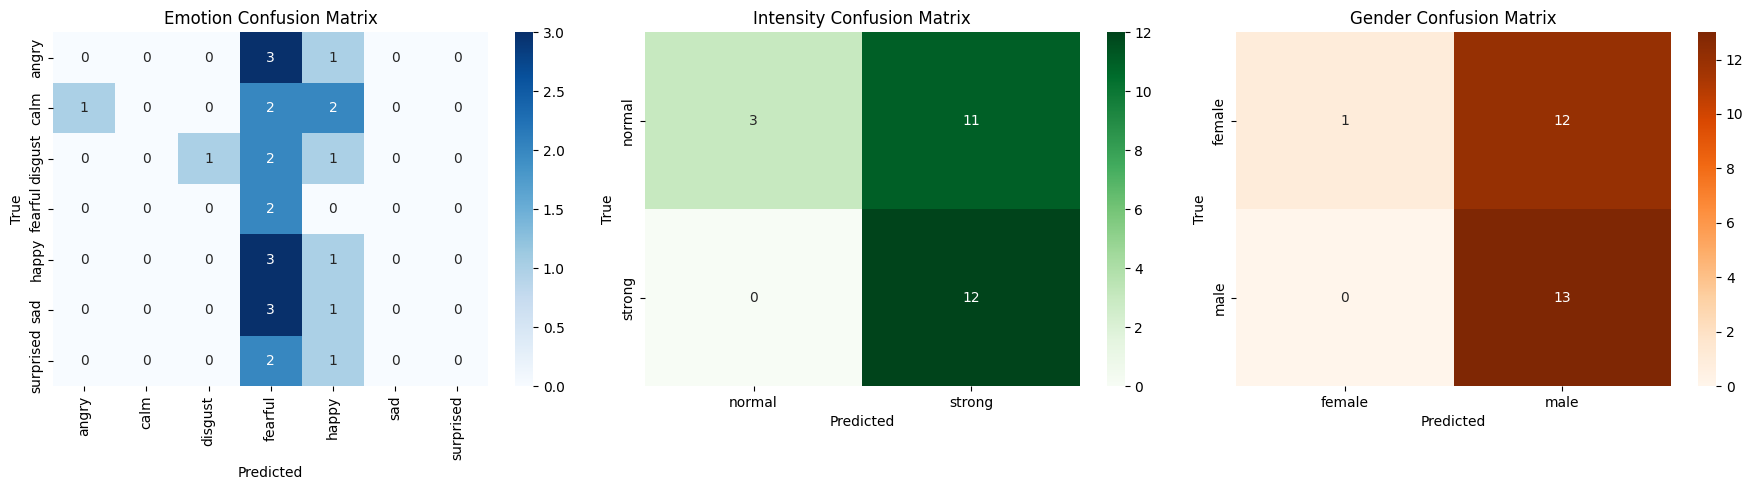

OVERALL ACCURACY
Emotion Accuracy:   15.38%
Intensity Accuracy: 57.69%
Gender Accuracy:    53.85%

EMOTION CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00         4
        calm       0.00      0.00      0.00         5
     disgust       1.00      0.25      0.40         4
     fearful       0.12      1.00      0.21         2
       happy       0.14      0.25      0.18         4
         sad       0.00      0.00      0.00         4
   surprised       0.00      0.00      0.00         3

    accuracy                           0.15        26
   macro avg       0.18      0.21      0.11        26
weighted avg       0.18      0.15      0.11        26


INTENSITY CLASSIFICATION REPORT
              precision    recall  f1-score   support

      normal       1.00      0.21      0.35        14
      strong       0.52      1.00      0.69        12

    accuracy                           0.58        26
   macro avg       0.76

In [23]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Re-run predictions to collect all results
test_metadata = pd.read_csv('test_metadata_master.csv')

true_emotions = []
pred_emotions = []
true_intensities = []
pred_intensities = []
true_genders = []
pred_genders = []

for _, row in test_metadata.iterrows():
    file_path = row['file_path']
    try:
        feature = extract_features_chunked(file_path)
        predictions = multi_svm.predict(feature.reshape(1, -1))[0]

        predicted_emotion = emotion_encoder.inverse_transform([predictions[0]])[0]
        predicted_intensity = intensity_encoder.inverse_transform([predictions[1]])[0]
        predicted_gender = gender_encoder.inverse_transform([predictions[2]])[0]

        # Align case with model label encoding (svm_improv uses lowercase labels)
        true_emotions.append(str(row['Emotion']).lower())
        pred_emotions.append(predicted_emotion)
        true_intensities.append(str(row['Intensity']).lower())
        pred_intensities.append(predicted_intensity)
        true_genders.append(str(row['Gender']).lower())
        pred_genders.append(predicted_gender)
    except Exception as e:
        print(f"Error processing {file_path}: {type(e).__name__}: {e}")

if len(true_emotions) == 0:
    print("No predictions were collected. Check file paths and model compatibility.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    cm_emotion = confusion_matrix(true_emotions, pred_emotions, labels=emotion_encoder.classes_)
    sns.heatmap(
        cm_emotion,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[0],
        xticklabels=emotion_encoder.classes_,
        yticklabels=emotion_encoder.classes_
    )
    axes[0].set_title('Emotion Confusion Matrix')
    axes[0].set_ylabel('True')
    axes[0].set_xlabel('Predicted')

    cm_intensity = confusion_matrix(true_intensities, pred_intensities, labels=intensity_encoder.classes_)
    sns.heatmap(
        cm_intensity,
        annot=True,
        fmt='d',
        cmap='Greens',
        ax=axes[1],
        xticklabels=intensity_encoder.classes_,
        yticklabels=intensity_encoder.classes_
    )
    axes[1].set_title('Intensity Confusion Matrix')
    axes[1].set_ylabel('True')
    axes[1].set_xlabel('Predicted')

    cm_gender = confusion_matrix(true_genders, pred_genders, labels=gender_encoder.classes_)
    sns.heatmap(
        cm_gender,
        annot=True,
        fmt='d',
        cmap='Oranges',
        ax=axes[2],
        xticklabels=gender_encoder.classes_,
        yticklabels=gender_encoder.classes_
    )
    axes[2].set_title('Gender Confusion Matrix')
    axes[2].set_ylabel('True')
    axes[2].set_xlabel('Predicted')

    plt.tight_layout()
    plt.show()

    emotion_acc = accuracy_score(true_emotions, pred_emotions)
    intensity_acc = accuracy_score(true_intensities, pred_intensities)
    gender_acc = accuracy_score(true_genders, pred_genders)

    print("=" * 60)
    print("OVERALL ACCURACY")
    print("=" * 60)
    print(f"Emotion Accuracy:   {emotion_acc:.2%}")
    print(f"Intensity Accuracy: {intensity_acc:.2%}")
    print(f"Gender Accuracy:    {gender_acc:.2%}")

    print("\n" + "=" * 60)
    print("EMOTION CLASSIFICATION REPORT")
    print("=" * 60)
    print(classification_report(
        true_emotions,
        pred_emotions,
        labels=emotion_encoder.classes_,
        target_names=emotion_encoder.classes_,
        zero_division=0
    ))

    print("\n" + "=" * 60)
    print("INTENSITY CLASSIFICATION REPORT")
    print("=" * 60)
    print(classification_report(
        true_intensities,
        pred_intensities,
        labels=intensity_encoder.classes_,
        target_names=intensity_encoder.classes_,
        zero_division=0
    ))

    print("\n" + "=" * 60)
    print("GENDER CLASSIFICATION REPORT")
    print("=" * 60)
    print(classification_report(
        true_genders,
        pred_genders,
        labels=gender_encoder.classes_,
        target_names=gender_encoder.classes_,
        zero_division=0
    ))